In [2]:
!pip install pymysql sqlalchemy pandas

In [9]:
import sqlite3
import pandas as pd
import os

# 1. Define the folder path where your 9 CSV files are saved
folder_path = r"E:\Shreyas Kamat files\PROJECTS\SQL"

# 2. Create/connect to a local SQLite database file
conn = sqlite3.connect('olist_project.db')

print("Starting import of all 9 tables into SQLite...\n")

# 3. Automatically loop through the folder and load every CSV file
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        
        # Clean the file name to create a clean table name 
        # (e.g., 'olist_customers_dataset.csv' becomes 'customers')
        table_name = file.replace('olist_', '').replace('_dataset.csv', '').replace('.csv', '')
        
        try:
            df = pd.read_csv(file_path)
            df.to_sql(table_name, conn, if_exists='replace', index=False)
            print(f"✅ Loaded: '{file}' ---> Table Name: '{table_name}' ({len(df):,} rows)")
        except Exception as e:
            print(f"❌ Error loading {file}: {e}")

print("\n🎉 All tables are successfully loaded into your SQLite database!")

Starting import of all 9 tables into SQLite...

✅ Loaded: 'olist_customers_dataset.csv' ---> Table Name: 'customers' (99,441 rows)
✅ Loaded: 'olist_geolocation_dataset.csv' ---> Table Name: 'geolocation' (1,000,163 rows)
✅ Loaded: 'olist_orders_dataset.csv' ---> Table Name: 'orders' (99,441 rows)
✅ Loaded: 'olist_order_items_dataset.csv' ---> Table Name: 'order_items' (112,650 rows)
✅ Loaded: 'olist_order_payments_dataset.csv' ---> Table Name: 'order_payments' (103,886 rows)
✅ Loaded: 'olist_order_reviews_dataset.csv' ---> Table Name: 'order_reviews' (99,224 rows)
✅ Loaded: 'olist_products_dataset.csv' ---> Table Name: 'products' (32,951 rows)
✅ Loaded: 'olist_sellers_dataset.csv' ---> Table Name: 'sellers' (3,095 rows)
✅ Loaded: 'product_category_name_translation.csv' ---> Table Name: 'product_category_name_translation' (71 rows)

🎉 All tables are successfully loaded into your SQLite database!


In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('olist_project.db')

# Let's inspect the columns of the translation table and products table
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(product_category_name_translation);")
print("Translation table columns:", [col[1] for col in cursor.fetchall()])

cursor.execute("PRAGMA table_info(products);")
print("Products table columns:", [col[1] for col in cursor.fetchall()])

Translation table columns: ['product_category_name', 'product_category_name_english']
Products table columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [13]:
import sqlite3

conn = sqlite3.connect('olist_project.db')
cursor = conn.cursor()
cursor.execute("PRAGMA table_info(order_items);")
print("Order Items table columns:", [col[1] for col in cursor.fetchall()])

Order Items table columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [14]:
import sqlite3
import pandas as pd

# 1. Connect to your SQLite database
conn = sqlite3.connect('olist_project.db')

# 2. Write the fully corrected multi-table JOIN query
master_query = """
SELECT 
    o.order_id,
    c.customer_state,
    o.order_status,
    p.product_category_name_english AS product_category,
    oi.price AS item_price,
    oi.freight_value,
    op.payment_type,
    op.payment_installments
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products pr ON oi.product_id = pr.product_id
LEFT JOIN product_category_name_translation p ON pr.product_category_name = p.product_category_name
JOIN order_payments op ON o.order_id = op.order_id
LIMIT 15;
"""

# 3. Execute and view the joined sample
df_master = pd.read_sql(master_query, conn)
print("Preview of the Master Relational Joined Dataset:")
print(df_master)

Preview of the Master Relational Joined Dataset:
                            order_id customer_state order_status  \
0   e481f51cbdc54678b7cc49136f2d6af7             SP    delivered   
1   e481f51cbdc54678b7cc49136f2d6af7             SP    delivered   
2   e481f51cbdc54678b7cc49136f2d6af7             SP    delivered   
3   53cdb2fc8bc7dce0b6741e2150273451             BA    delivered   
4   47770eb9100c2d0c44946d9cf07ec65d             GO    delivered   
5   949d5b44dbf5de918fe9c16f97b45f8a             RN    delivered   
6   ad21c59c0840e6cb83a9ceb5573f8159             SP    delivered   
7   a4591c265e18cb1dcee52889e2d8acc3             PR    delivered   
8   136cce7faa42fdb2cefd53fdc79a6098             RS     invoiced   
9   6514b8ad8028c9f2cc2374ded245783f             RJ    delivered   
10  76c6e866289321a7c93b82b54852dc33             RS    delivered   
11  e69bfb5eb88e0ed6a785585b27e16dbf             SP    delivered   
12  e69bfb5eb88e0ed6a785585b27e16dbf             SP    delivered   

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21724\1653847812.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


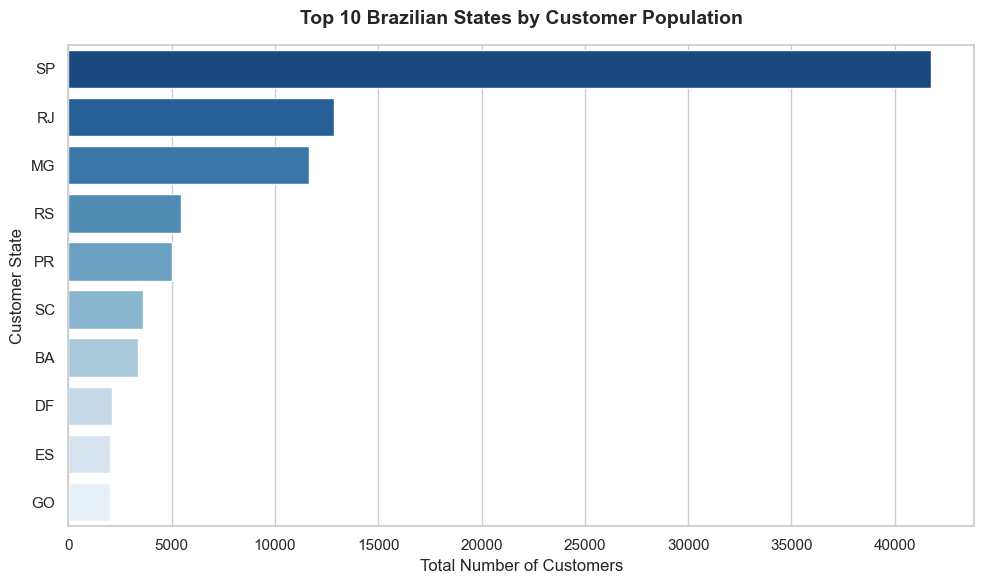

In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your SQLite database
conn = sqlite3.connect('olist_project.db')

# 2. Run the SQL query to get customer distribution by state
query = """
SELECT 
    customer_state,
    COUNT(customer_id) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC
LIMIT 10;
"""

df_plot = pd.read_sql(query, conn)

# 3. Set up a clean plot style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Create a horizontal bar chart (easy to read state labels)
ax = sns.barplot(
    x='total_customers', 
    y='customer_state', 
    data=df_plot, 
    palette='Blues_r'
)

# 5. Add titles and clean labels
plt.title('Top 10 Brazilian States by Customer Population', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Number of Customers', fontsize=12)
plt.ylabel('Customer State', fontsize=12)

# 6. Display the plot clearly
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21724\2596703905.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='total_sold', y='product_category', data=df, palette='crest')


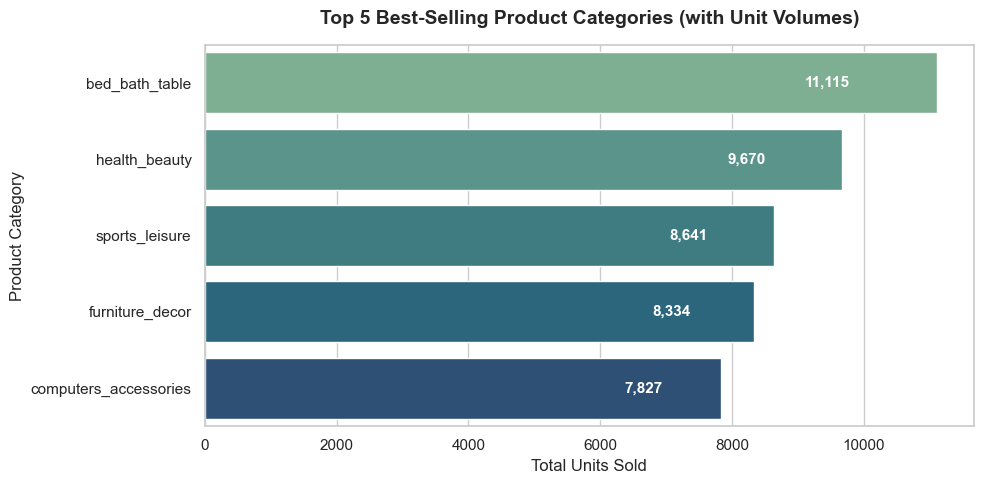

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('olist_project.db')
sns.set_theme(style="whitegrid")

# Query top categories
query = """
SELECT 
    p.product_category_name_english AS product_category,
    COUNT(oi.order_item_id) AS total_sold
FROM order_items oi
JOIN products pr ON oi.product_id = pr.product_id
LEFT JOIN product_category_name_translation p ON pr.product_category_name = p.product_category_name
WHERE product_category IS NOT NULL
GROUP BY product_category
ORDER BY total_sold DESC
LIMIT 5;
"""
df = pd.read_sql(query, conn)

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='total_sold', y='product_category', data=df, palette='crest')

# Add exact value labels on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,}', 
                (width - (width * 0.15), p.get_y() + p.get_height() / 2.),
                ha='center', va='center', 
                fontsize=11, color='white', fontweight='bold')

plt.title('Top 5 Best-Selling Product Categories (with Unit Volumes)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('olist_project.db')

# RFM Calculation Query
rfm_query = """
WITH customer_rfm AS (
    SELECT 
        c.customer_unique_id,
        CAST(JULIANDAY('2018-10-17') - JULIANDAY(MAX(o.order_purchase_timestamp)) AS INTEGER) AS recency_days,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(op.payment_value), 2) AS monetary
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_payments op ON o.order_id = op.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT * FROM customer_rfm
ORDER BY monetary DESC
LIMIT 10;
"""

df_rfm = pd.read_sql(rfm_query, conn)
print("Top 10 Customers by Monetary Value (RFM Table Sample):")
print(df_rfm)

Top 10 Customers by Monetary Value (RFM Table Sample):
                 customer_unique_id  recency_days  frequency  monetary
0  0a0a92112bd4c708ca5fde585afaa872           382          1  13664.08
1  da122df9eeddfedc1dc1f5349a1a690c           563          2   7571.63
2  763c8b1c9c68a0229c42c9fc6f662b93            93          1   7274.88
3  dc4802a71eae9be1dd28f5d788ceb526           611          1   6929.31
4  459bef486812aa25204be022145caa62            83          1   6922.21
5  ff4159b92c40ebe40454e3e6a7c35ed6           510          1   6726.66
6  4007669dec559734d6f53e029e360987           326          1   6081.54
7  eebb5dda148d3893cdaf5b5ca3040ccb           546          1   4764.34
8  48e1ac109decbb87765a3eade6854098           116          1   4681.78
9  c8460e4251689ba205045f3ea17884a1            69          4   4655.91


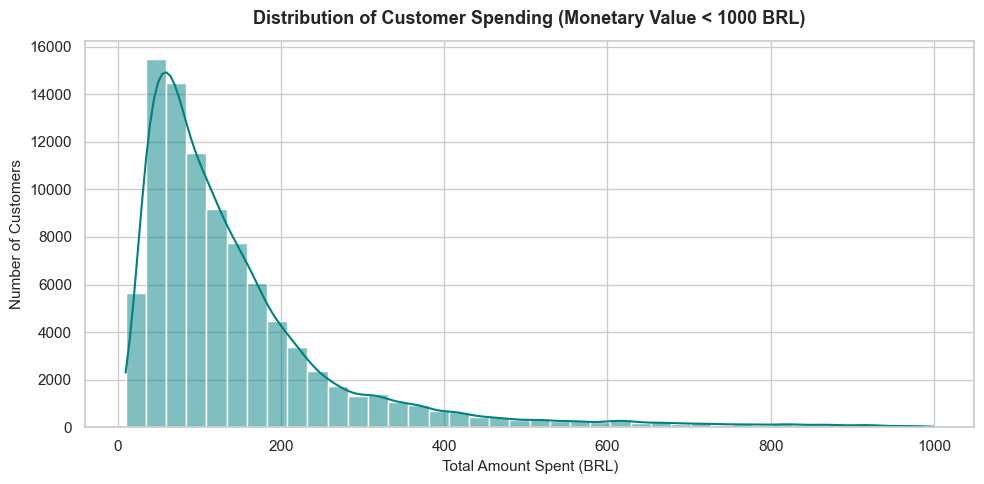

In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('olist_project.db')
sns.set_theme(style="whitegrid")

# Get customer monetary values (filtering extreme outliers for a clean plot)
monetary_query = """
SELECT 
    SUM(op.payment_value) AS monetary
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_payments op ON o.order_id = op.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
HAVING monetary < 1000;
"""
df_monetary = pd.read_sql(monetary_query, conn)

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_monetary['monetary'], bins=40, kde=True, color='teal')
plt.title('Distribution of Customer Spending (Monetary Value < 1000 BRL)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Total Amount Spent (BRL)', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.tight_layout()
plt.show()

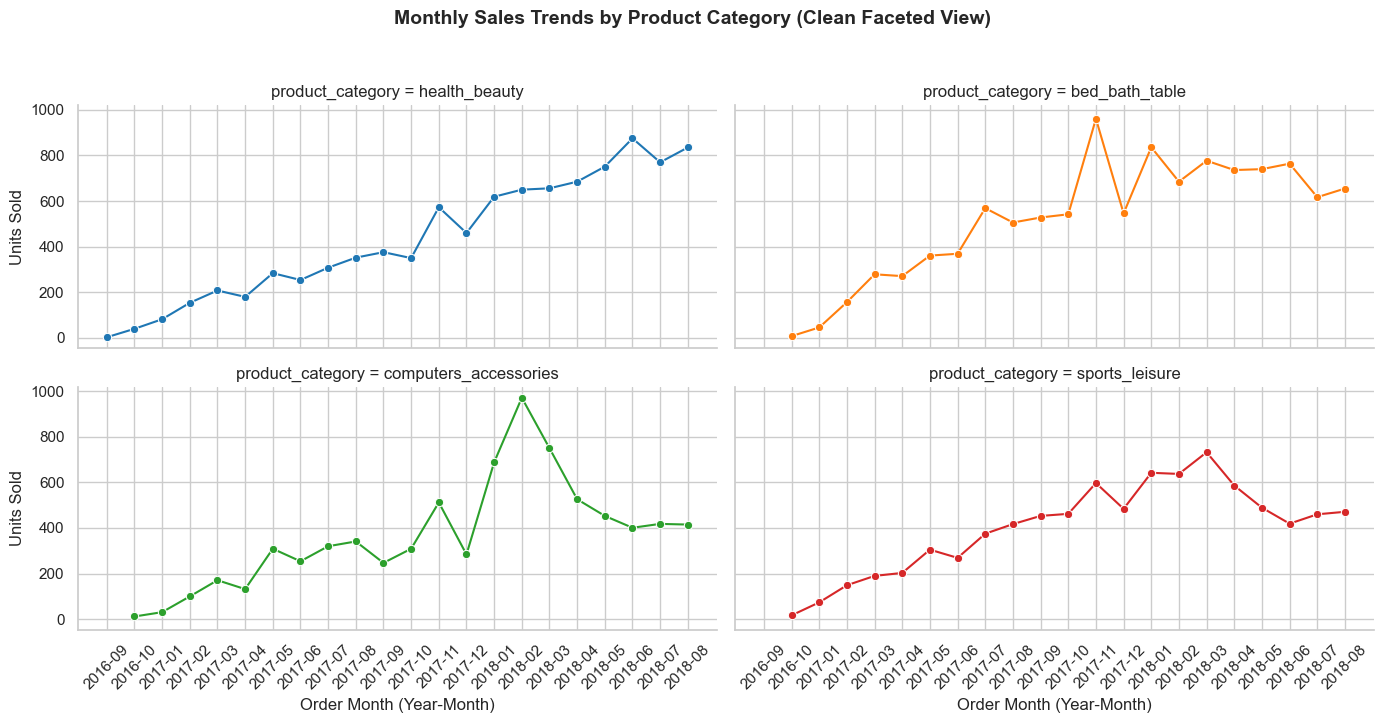

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('olist_project.db')
sns.set_theme(style="whitegrid")

# Query monthly sales trends for top categories
timeseries_query = """
SELECT 
    STRFTIME('%Y-%m', o.order_purchase_timestamp) AS order_month,
    p.product_category_name_english AS product_category,
    COUNT(oi.order_item_id) AS monthly_units
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products pr ON oi.product_id = pr.product_id
JOIN product_category_name_translation p ON pr.product_category_name = p.product_category_name
WHERE o.order_status = 'delivered'
  AND p.product_category_name_english IN ('bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories')
GROUP BY order_month, product_category
ORDER BY order_month;
"""

df_ts = pd.read_sql(timeseries_query, conn)

# Use relplot to create separate clean panels for each category
g = sns.relplot(
    data=df_ts, 
    x='order_month', 
    y='monthly_units', 
    hue='product_category', 
    col='product_category', 
    col_wrap=2, 
    kind='line', 
    marker='o', 
    height=3.5, 
    aspect=2,
    palette='tab10',
    legend=False
)

g.fig.suptitle('Monthly Sales Trends by Product Category (Clean Faceted View)', y=1.03, fontsize=14, fontweight='bold')
g.set_axis_labels('Order Month (Year-Month)', 'Units Sold')

# Rotate x-axis ticks for readability on all subplots
for ax in g.axes.flat:
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

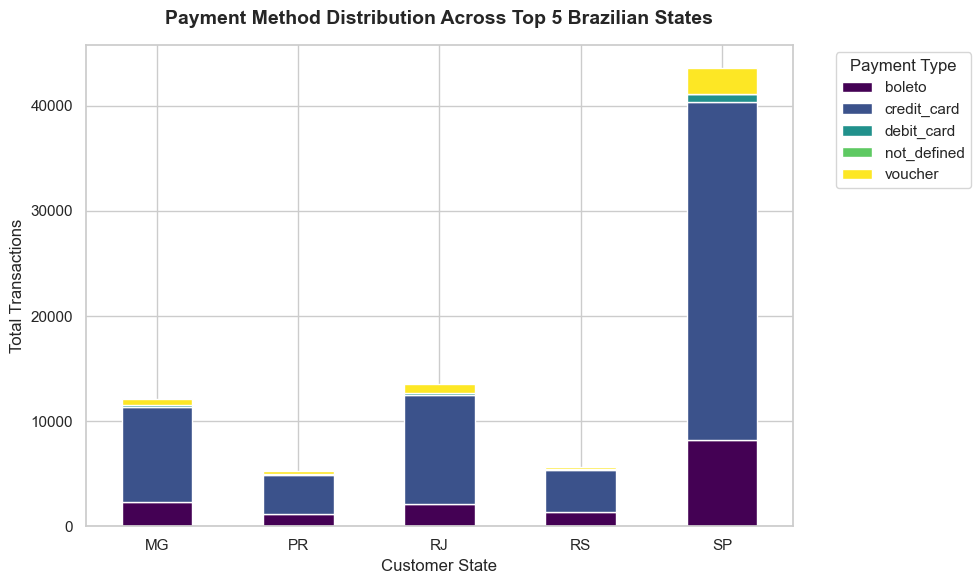

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('olist_project.db')
sns.set_theme(style="whitegrid")

# 1. Query payment types across top states
pay_geo_query = """
SELECT 
    c.customer_state,
    op.payment_type,
    COUNT(op.order_id) AS total_transactions
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_payments op ON o.order_id = op.order_id
WHERE c.customer_state IN ('SP', 'RJ', 'MG', 'RS', 'PR')
GROUP BY c.customer_state, op.payment_type;
"""

df_pg = pd.read_sql(pay_geo_query, conn)

# 2. Pivot the table so payment types become columns for a stacked bar chart
df_pivot = df_pg.pivot(index='customer_state', columns='payment_type', values='total_transactions').fillna(0)

# 3. Plot stacked bar chart
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Payment Method Distribution Across Top 5 Brazilian States', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Payment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()